**Neural Network**

In [1]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
nn_architecture = [
    {"input_dim":2, "output_dim":4, "activation":"relu"},
    {"input_dim":4, "output_dim":6, "activation":"relu"},
    {"input_dim":6, "output_dim":6, "activation":"relu"},
    {"input_dim":6, "output_dim":4, "activation":"relu"},
    {"input_dim":4, "output_dim":1, "activation":"sigmoid"}
]

In [3]:
def init_layers(nn_architecture, seed=99):

    np.random.seed(seed)
    params_values = {}

    for idx, layer in enumerate(nn_architecture):

        layer_idx = idx + 1

        params_values['W' + str(layer_idx)] = np.random.randn(
            layer["output_dim"],
            layer["input_dim"]
        ) * 0.1

        params_values['b' + str(layer_idx)] = np.zeros(
            (layer["output_dim"], 1)
        )

    return params_values

In [4]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def relu(x):
  return np.maximum(0, x)

def sigmoid_backward(dA, x):
  sig = sigmoid(x)
  return dA * sig * (1 - sig)

def relu_backward(dA, x):
  dx = np.array(dA, copy=True)
  dx[x <= 0] = 0
  return dx


In [5]:
def convert_prob_into_class(probs):
  """Converts probabilities into binary classes (0 or 1)."""
  return (probs > 0.5).astype(int)

In [6]:
def single_layer_forward_propagation(A_prev, W_curr, b_curr, activation="relu"):
  Z_curr = np.dot(W_curr, A_prev) + b_curr
  if activation == "relu":
    activation_func = relu
  elif activation == "sigmoid":
    activation_func = sigmoid
  else:
    raise Exception('Non-supported activation function')
  return activation_func(Z_curr), Z_curr

In [7]:
def full_forward_propagation(X, params_values, nn_architecture):

    memory = {}
    A_curr = X

    for idx, layer in enumerate(nn_architecture):
        layer_idx = idx + 1
        A_prev = A_curr

        A_curr, Z_curr = single_layer_forward_propagation(
            A_prev,
            params_values["W" + str(layer_idx)],
            params_values["b" + str(layer_idx)],
            layer["activation"]
        )

        memory["A" + str(idx)] = A_prev
        memory["Z" + str(layer_idx)] = Z_curr

    return A_curr, memory

In [8]:
# Cross Entropy
def get_cost_value(Y_hat, Y):
  m = Y_hat.shape[1]
  cost = -1 / m * (np.dot(Y, np.log(Y_hat).T) + np.dot(1 - Y, np.log(1 - Y_hat).T))
  return np.squeeze(cost)

In [9]:
def get_accuracy_value(Y_hat, Y):
  Y_hat_class = convert_prob_into_class(Y_hat)
  return (Y_hat_class == Y).mean()

In [10]:
def single_layer_backward_propagation(dA_curr, W_curr, b_curr, Z_curr, A_prev, activation="relu"):
    m = A_prev.shape[1]
    if activation == "relu":
        backward_activation_func = relu_backward
    elif activation == "sigmoid":
        backward_activation_func = sigmoid_backward
    else:
        raise Exception('Non-supported activation function')

    dZ_curr = backward_activation_func(dA_curr, Z_curr)
    dW_curr = np.dot(dZ_curr, A_prev.T) / m
    db_curr = np.sum(dZ_curr, axis=1, keepdims=True) / m
    dA_prev = np.dot(W_curr.T, dZ_curr)
    return dA_prev, dW_curr, db_curr

In [11]:
def full_backward_propagation(Y_hat, Y, memory, params_values, nn_architecture):
    grads_values = {}
    Y = Y.reshape(Y_hat.shape)
    dA_prev = - (np.divide(Y, Y_hat) - np.divide(1 - Y, 1 - Y_hat))

    for layer_idx_prev, layer in reversed(list(enumerate(nn_architecture))):
        layer_idx_curr = layer_idx_prev + 1
        dA_prev, dW_curr, db_curr = single_layer_backward_propagation(
            dA_prev,
            params_values["W" + str(layer_idx_curr)],
            params_values["b" + str(layer_idx_curr)],
            memory["Z" + str(layer_idx_curr)],
            memory["A" + str(layer_idx_prev)],
            layer["activation"]
        )
        grads_values["dW" + str(layer_idx_curr)] = dW_curr
        grads_values["db" + str(layer_idx_curr)] = db_curr
    return grads_values

In [12]:
def update(params_values, grads_values, nn_architecture, learning_rate):
    for idx, _ in enumerate(nn_architecture):
        layer_idx = idx + 1
        params_values["W" + str(layer_idx)] -= learning_rate * grads_values["dW" + str(layer_idx)]
        params_values["b" + str(layer_idx)] -= learning_rate * grads_values["db" + str(layer_idx)]
    return params_values

In [13]:
def train(X, Y, nn_architecture, epochs, learning_rate):
    params_values = init_layers(nn_architecture, 2)
    cost_history = []
    accuracy_history = []

    for i in range(epochs):
        Y_hat, memory = full_forward_propagation(X, params_values, nn_architecture)
        cost = get_cost_value(Y_hat, Y)
        cost_history.append(cost)
        accuracy = get_accuracy_value(Y_hat, Y)
        accuracy_history.append(accuracy)

        grads_values = full_backward_propagation(Y_hat, Y, memory, params_values, nn_architecture)
        params_values = update(params_values, grads_values, nn_architecture, learning_rate)

        if i % 1000 == 0:
            print(f"Iteration: {i} - cost: {cost:.5f} - accuracy: {accuracy:.5f}")

    return params_values, cost_history, accuracy_history

Iteration: 0 - cost: 0.69316 - accuracy: 0.50000
Iteration: 1000 - cost: 0.69311 - accuracy: 0.79125
Iteration: 2000 - cost: 0.69310 - accuracy: 0.86125
Iteration: 3000 - cost: 0.69309 - accuracy: 0.85750
Iteration: 4000 - cost: 0.69308 - accuracy: 0.85500
Iteration: 5000 - cost: 0.69307 - accuracy: 0.85250
Iteration: 6000 - cost: 0.69306 - accuracy: 0.85125
Iteration: 7000 - cost: 0.69305 - accuracy: 0.84625
Iteration: 8000 - cost: 0.69303 - accuracy: 0.84000
Iteration: 9000 - cost: 0.69300 - accuracy: 0.83500


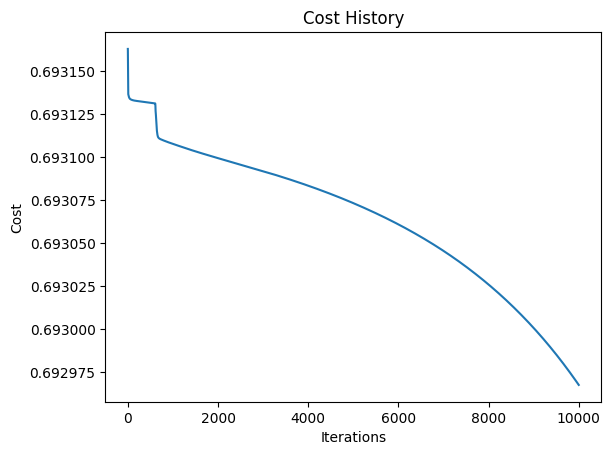

In [14]:
x , y = make_moons(n_samples=1000, noise=0.1, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Transpose for the NN(Features x samples)
x_train = x_train.T
y_train = y_train.reshape(1 , -1)

#train
params_values, cost_history, accuracy_history = train(x_train, y_train, nn_architecture, epochs=10000, learning_rate=0.01)

plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost History")
plt.show()